In [1]:
import chipwhisperer as cw
import chipwhisperer.common.results.glitch as glitch
import numpy as np
import time

# --- USER CONFIGURATION ---
# *** IMPORTANT:BITSTREAM PATH ***
BITSTREAM_FILEPATH = r'C:\Users\sbista\ChipWhisperer\chipwhisperer\firmware\fpgas\aes\vivado\cw305_aes.runs\impl_100t\cw305_top.bit'

# Set a fixed key and plaintext for consistent testing
KEY = bytearray([0x2B, 0x7E, 0x15, 0x16, 0x28, 0xAE, 0xD2, 0xA6, 0xAB, 0xF7, 0x15, 0x88, 0x09, 0xCF, 0x4F, 0x3C])
PLAINTEXT = bytearray([0x5C, 0x69, 0x2F, 0x91, 0x03, 0xB2, 0x30, 0x29, 0x14, 0xD7, 0xE5, 0x55, 0xE4, 0xDC, 0xEE, 0x49])
EXPECTED_CIPHERTEXT = bytearray([0x06, 0xF3, 0x6A, 0x65, 0xE8, 0xA9, 0x9F, 0xF8, 0x90, 0x7B, 0x2E, 0x5E, 0x5D, 0xDD, 0x77, 0xDE])

#expected=06f36a65e8a99ff8907b2e5e5ddd77de
#outputou=06f36a65e8a99ff8907b2e5e5ddd77de
          #04f36a65e8a99fd8907b0e5e5ddd77de
#0.88targ=04f36a65e8a99ff8907b2e5e5ddd77de
#0.86targ=04f36a65e8a99ff8907b2e5e5ddd77de
#0.87targ=04f36a65e8a99dd8907b0e5e5ddd57de
#0.8799999=04f36a65e8a99ff8907b2e5e5ddd77de
#0.86targ=04d14845c8899dd890590c5c5ddd54dc
# Attack Parameters

NUM_GLITCH_ATTEMPTS = 500 # Number of times to try glitching
NUM_NORMAL_TRACES = 10000 # Number of traces without glitch for comparison
#VCC_INT_TARGET = 0.87
# --- CONNECTION ---
scope = cw.scope()
target = cw.target(scope, cw.targets.CW305, bsfile=BITSTREAM_FILEPATH, force=True)

(ChipWhisperer Target WARNING|File CW305.py:591) Using default Verilog defines (C:\Users\sbista\ChipWhisperer\chipwhisperer\software\chipwhisperer/hardware/firmware/cw305/cw305_aes_defines.v); if this is not what you want, provide them via the defines_files argument


In [2]:
print(f"Target VCC-INT set to: {target.vccint_get()}V")

# Setup PLL1 on CW305 (assuming 10MHz external clock is provided by CW-Lite)
target.pll.pll_outfreq_set(5E6, 1) # Set PLL1 to 50 MHz (common FPGA clock)
target.pll.pll_enable_set(True)
target.pll.pll_outenable_set(True, 1)

# --- CONFIGURE CW-LITE SCOPE FOR POWER TRACING ---
# Use the clock generated by the CW305 (EXTCLK) as the ADC clock source
scope.default_setup()
scope.clock.adc_src = "extclk_x4" # Use 4x the target clock for sampling
scope.adc.samples = 40 # Number of samples to capture per trace
scope.adc.offset = 0
scope.gain.gain = 25
scope.adc.presamples = 0
scope.adc.basic_mode = "falling_edge"
scope.trigger.triggers = 'tio4' # FPGA trigger pin TIO4 is used to arm the scope/glitch
scope.io.tio1 = "serial_tx"
scope.io.tio2 = "serial_rx"
scope.io.tio3 = "high_z" # Not used
scope.io.tio4 = "high_z" # Used for trigger, set by FPGA
import time
for i in range(5):
    scope.clock.reset_adc()
    time.sleep(1)
    if scope.clock.adc_locked:
        break 
assert (scope.clock.adc_locked), "ADC failed to lock"

Target VCC-INT set to: 1.0V
scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 399761845                 to 411968603                
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 96000000                  to 29538459                 
scope.clock.adc_rate                     changed from 96000000.0                to 29538459.0       

In [3]:
def run_aes(target, plaintext, key):
    target.set_key(key)
    target.simpleserial_write('p', plaintext)
    # The target.go() is handled by simpleserial_write for the CW305 target
    
    # Read the output from the target
    try:
        response = target.simpleserial_read('r', 16)
        if len(response) == 16:
            return response, True
        else:
            return None, False
    except Exception as e:
        print(f"Target read error: {e}")
        return None, False

In [4]:
scope.io.glitch_lp = False     # CW305 uses LP glitch
scope.io.glitch_hp = False
for i in range(10):
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    
    if scope.capture():
        print("Timeout – no trigger seen")
        continue


    if ok and out != EXPECTED_CIPHERTEXT:
        print("REAL GLITCH FAULT FOUND:", out.hex())
        break
    else:
        print("normal",out.hex())


normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de


In [5]:
## --- 2. CAPTURE NORMAL TRACES ---
print("\n--- Collecting Normal Traces ---")
# Storage for the normal traces
normal_traces = []

for i in range(NUM_NORMAL_TRACES):
    scope.arm()
    output, success = run_aes(target, PLAINTEXT, KEY)
    
    if scope.capture():
        print(f"Timeout occurred on trace {i}")
        continue

    trace = scope.get_last_trace()
    normal_traces.append(trace)
    
    # Verify the output is the expected ciphertext
    #if output == EXPECTED_CIPHERTEXT:
        #print(f"Trace {i}: Success, Output: {output.hex()}")
    #else:
        #print(f"Trace {i}: FAIL, Output: {output.hex() if output else 'N/A'}")

    if output != EXPECTED_CIPHERTEXT:
        print(f"Trace {i}: FAIL, Output: {output.hex() if output else 'N/A'}")
        
print(f"Baseline trace collection complete. Collected {len(normal_traces)} good traces.")



--- Collecting Normal Traces ---
Baseline trace collection complete. Collected 10000 good traces.


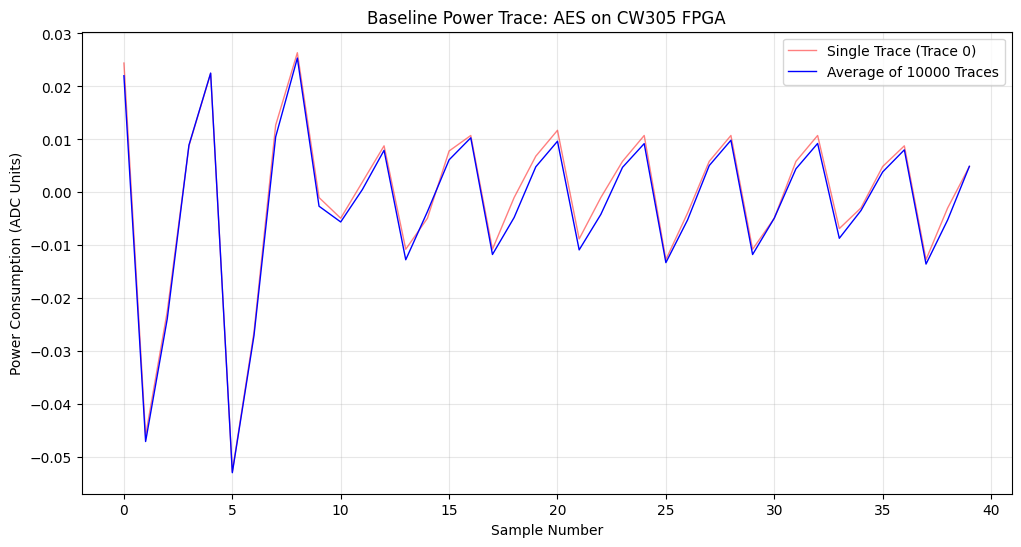

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure your normal_traces list has data
if not normal_traces:
    print("Error: No traces were collected. Run the 'Normal Trace Collection' loop first.")
else:
    # --- PLOT SETUP ---
    
    # 1. Get the first trace as a baseline
    first_trace = np.array(normal_traces[0])
    
    # 2. Get the average of all collected traces (provides a cleaner view)
    average_trace = np.average(normal_traces, axis=0)
    
    # --- PLOTTING ---
    plt.figure(figsize=(12, 6))
    
    # Plot the first collected trace
    plt.plot(first_trace, label="Single Trace (Trace 0)", color='red', alpha=0.5,linewidth=1)
    
    # Plot the average trace
    plt.plot(average_trace, label=f"Average of {len(normal_traces)} Traces", color='blue', linewidth=1)
    
    plt.title("Baseline Power Trace: AES on CW305 FPGA")
    plt.xlabel("Sample Number")
    plt.ylabel("Power Consumption (ADC Units)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [8]:
print("ADC src:", scope.clock.adc_src)
print("Trigger:", scope.trigger.triggers)
print("Basic mode:", scope.adc.basic_mode)
print("Samples:", scope.adc.samples)

ADC src: extclk_x4
Trigger: tio4
Basic mode: falling_edge
Samples: 400


In [30]:
# Enable glitch path
scope.io.glitch_lp = True     # CW305 uses LP glitch
scope.io.glitch_hp = False

scope.glitch.repeat = 1
scope.glitch.trigger_src = 'ext_single'  # standard
scope.glitch.width  = 0.8
scope.glitch.offset = -20.0
for i in range(10):
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    
    if scope.capture():
        print("Timeout – no trigger seen")
        continue
    if ok and out != EXPECTED_CIPHERTEXT:
        print("REAL GLITCH FAULT FOUND:", out.hex())
    else:
        print("normal",out.hex())

REAL GLITCH FAULT FOUND: 06f36a65c8a99ff8907b2e5e5ddc77dc
REAL GLITCH FAULT FOUND: 04d16a65e8a99ff890592e5e5ddd77de
REAL GLITCH FAULT FOUND: 04f36a65e8a99ff890582e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
REAL GLITCH FAULT FOUND: 06f36a65c8a99ff8907b2e5e5ddd77dc
REAL GLITCH FAULT FOUND: 04f36a65e8a99ff8907b2e5e5ddd77de
REAL GLITCH FAULT FOUND: 06f36a65c8a99ff8907b2e5e5ddd77de
REAL GLITCH FAULT FOUND: 06f36a65e8a99cf8907b2e5e5ddd55de
REAL GLITCH FAULT FOUND: 06f36a65e8889ff8907b2e5e5ddd54dc
REAL GLITCH FAULT FOUND: 06f36a45e8a99ff8907b2e5e5cdd77de


In [10]:
def diff_bytes(a, b):
    return sum(x != y for x, y in zip(a, b))
N = 1000
faults = 0
hist = {}
for i in range(N):
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    if scope.capture() or (not ok) or out is None:
        continue

    d = diff_bytes(out, EXPECTED_CIPHERTEXT)
    hist[d] = hist.get(d, 0) + 1
    if d != 0:
        faults += 1
print("Fault rate:", faults / N)
print("Diff-bytes histogram:", dict(sorted(hist.items())))

Fault rate: 0.949
Diff-bytes histogram: {0: 51, 1: 258, 2: 466, 3: 205, 4: 20}


In [11]:
from collections import Counter

pos_ctr = Counter()

for i in range(N):
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    if scope.capture() or (not ok) or out is None:
        continue
    if out == EXPECTED_CIPHERTEXT:
        continue
    for idx, (a,b) in enumerate(zip(out, EXPECTED_CIPHERTEXT)):
        if a != b:
            pos_ctr[idx] += 1

print("Byte position fault counts (0..15):")
print(dict(sorted(pos_ctr.items())))


Byte position fault counts (0..15):
{0: 186, 1: 138, 2: 132, 3: 135, 4: 128, 5: 107, 6: 143, 7: 131, 9: 153, 10: 147, 11: 115, 12: 68, 13: 62, 14: 119, 15: 117}


In [13]:
mask_ctr = Counter()

for i in range(N):
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    if scope.capture() or (not ok) or out is None:
        continue
    if out == bytes(EXPECTED_CIPHERTEXT):
        continue
    masks = bytes([x ^ y for x,y in zip(out, EXPECTED_CIPHERTEXT)])
    mask_ctr[masks.hex()] += 1

print("Top 10 XOR masks:")
for m,c in mask_ctr.most_common(10):
    print(c, m)


Top 10 XOR masks:
135 00000000000000200000000000000000
76 00002200000000000000000200000000
61 02000000000000000023000000000000
58 00000000000003000000000000000000
53 00000000200000000000000000010002
46 00000000002100000000000000002300
37 02000000000000000000000000000000
36 00000020000000000000000001000000
29 00000000000002200000000000000000
29 00230000000000000000220000000000


In [ ]:
for off in np.linspace(-40, 40, 90):
    scope.glitch.offset = off
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    scope.capture()
    if ok and out != EXPECTED_CIPHERTEXT:
        print("FAULT at offset", off, out.hex())


In [8]:
glitched_results = []
successful_faults = 0
total_attempts_run = 0


# Enable glitch path
scope.io.glitch_lp = True    # CW305 uses LP glitch
scope.io.glitch_hp = False
scope.glitch.repeat = 1
scope.glitch.trigger_src = 'ext_single'  # standard
scope.glitch.width  = 0.8
scope.glitch.offset = -20.0
for i in range(10):
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    
    if scope.capture():
        print("Timeout – no trigger seen")
        continue
    if ok and out != EXPECTED_CIPHERTEXT:
        print("REAL GLITCH FAULT FOUND:", out.hex())
    else:
        print("normal",out.hex())




# --- INITIALIZE FOR SINGLE ATTEMPT ---
glitched_trace_for_plot = None
attempt_result = None


print(f"\n--- COLLECTING SINGLE FAULT TRACE")

# Run loop until a successful fault trace is collected (max 10 attempts for stability)
for i in range(10000): 
    scope.arm()
    output, success = run_aes(target, PLAINTEXT, KEY)

    if scope.capture():
        # Handle crash (reprogram if needed)
        try:
            target.fpga_write(BITSTREAM_FILEPATH)
            print(f"Attempt {i}: TIMEOUT. Reprogrammed.")
        except:
            pass
        continue

    output_hex = output.hex()
    expected_hex = EXPECTED_CIPHERTEXT.hex()
    
    if output_hex != expected_hex and success:
        # A true fault occurred, and communication was successful
        glitched_trace_for_plot = scope.get_last_trace()
        attempt_result = output_hex
        #print(f"SUCCESS: Fault Trace Collected. Output: {attempt_result}")
    else:
        # Normal run, not crash. Continue attempting.
        print(f"Attempt {i}: Normal result. Re-attempting fault...")


REAL GLITCH FAULT FOUND: 06f36a65e8899ff8907b2e5e5ddd77dc
REAL GLITCH FAULT FOUND: 04f36a65e8a99ff8907b2e5e5ddd77de
REAL GLITCH FAULT FOUND: 04f36a65e8a99ff890582e5e5ddd77de
REAL GLITCH FAULT FOUND: 06f36a65e8a99fd8907b2e5e5ddd77de
REAL GLITCH FAULT FOUND: 06f36a65e8889ff8907b2e5e5ddd57dc
REAL GLITCH FAULT FOUND: 06f36a65e8a99fd8907b2e5e5ddd77de
REAL GLITCH FAULT FOUND: 06f36a65c8a99ff8907b2e5e5ddc77dc
REAL GLITCH FAULT FOUND: 06d06a65e8a99ff8907b0c5e5ddd77de
REAL GLITCH FAULT FOUND: 06f36a65e8a99cf8907b2e5e5ddd77de
REAL GLITCH FAULT FOUND: 06f36a65e8a99cf8907b2e5e5ddd77de

--- COLLECTING SINGLE FAULT TRACE
Attempt 2: Normal result. Re-attempting fault...
Attempt 15: Normal result. Re-attempting fault...
Attempt 32: Normal result. Re-attempting fault...
Attempt 37: Normal result. Re-attempting fault...
Attempt 52: Normal result. Re-attempting fault...
Attempt 66: Normal result. Re-attempting fault...
Attempt 74: Normal result. Re-attempting fault...
Attempt 81: Normal result. Re-attemp

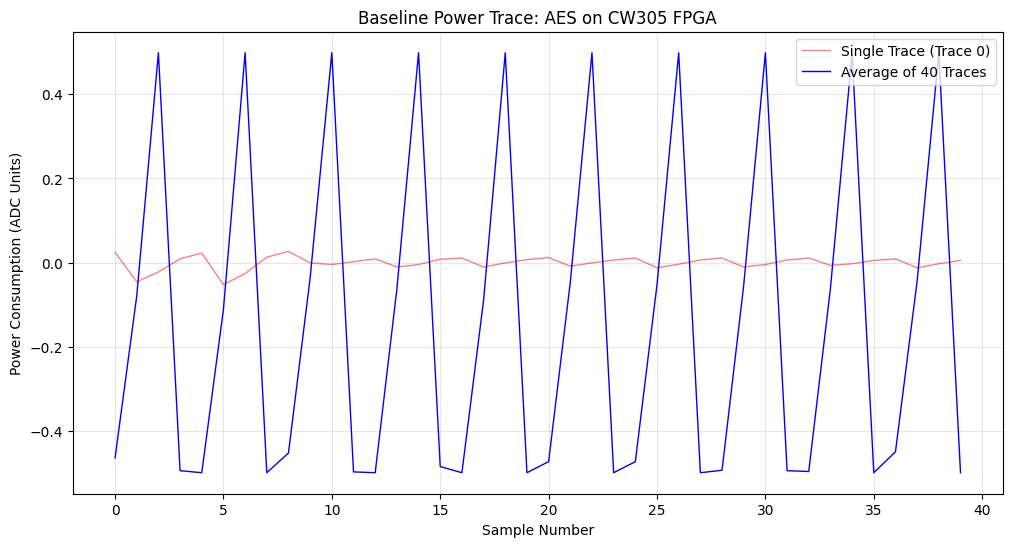

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure your normal_traces list has data
if glitched_trace_for_plot is None:
    print("Error: No traces were collected. Run the 'Normal Trace Collection' loop first.")
else:
    # --- PLOT SETUP ---
    
    # 1. Get the first trace as a baseline
    #first_trace = np.array(glitched_trace_for_plot[0])
    
    # 2. Get the average of all collected traces (provides a cleaner view)
    #average_trace = np.average(glitched_trace_for_plot, axis=0)
    baseline_trace = np.array(normal_traces[0])
    glitched_trace = np.array(glitched_trace_for_plot)
    # --- PLOTTING ---
    plt.figure(figsize=(12, 6))
    
    # Plot the first collected trace
    plt.plot(baseline_trace, label="Single Trace (Trace 0)", color='red', alpha=0.5,linewidth=1)
    
    # Plot the average trace
    plt.plot(glitched_trace, label=f"Average of {len(glitched_trace_for_plot)} Traces", color='blue', linewidth=1)
    
    plt.title("Baseline Power Trace: AES on CW305 FPGA")
    plt.xlabel("Sample Number")
    plt.ylabel("Power Consumption (ADC Units)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

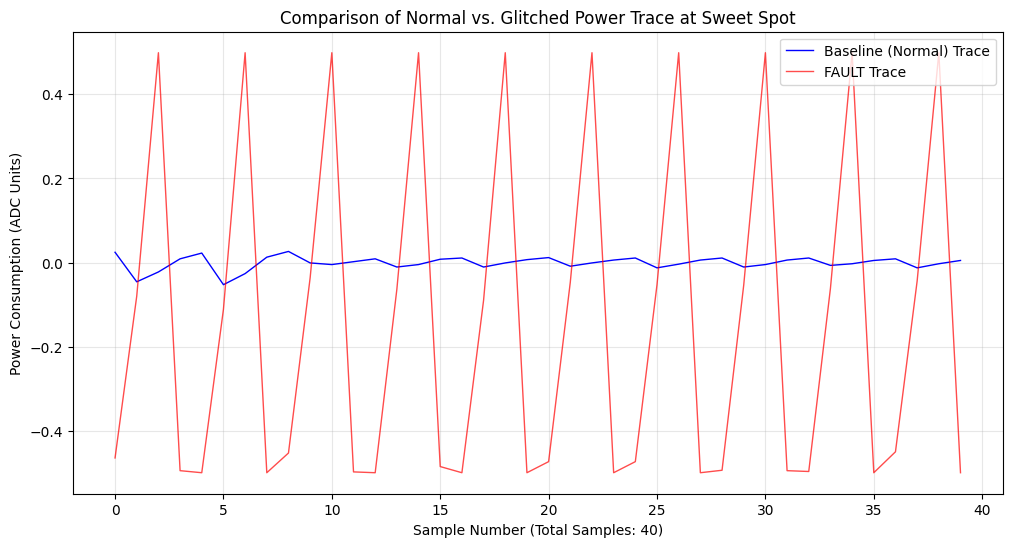

In [10]:
import matplotlib.pyplot as plt
import numpy as np

if glitched_trace_for_plot is None:
    print("\nError: Failed to capture a valid FAULT trace after 10 attempts. Check VCC_FINAL/Offset settings.")
else:
    # --- PREPARE PLOT DATA ---
    baseline_trace = np.array(normal_traces[0])
    glitched_trace = np.array(glitched_trace_for_plot)
    
    # Ensure traces have the same length
    min_len = min(len(glitched_trace), len(baseline_trace))
    glitched_trace = glitched_trace[:min_len]
    baseline_trace = baseline_trace[:min_len]

    # --- PLOT THE COMPARISON ---
    plt.figure(figsize=(12, 6))
    
    plt.plot(baseline_trace, label="Baseline (Normal) Trace", color='blue', linewidth=1)
    plt.plot(glitched_trace, 
             label=f"FAULT Trace", 
             color='red', linewidth=1.0, alpha=0.7)
    
    plt.title("Comparison of Normal vs. Glitched Power Trace at Sweet Spot")
    plt.xlabel(f"Sample Number (Total Samples: {min_len})")
    plt.ylabel("Power Consumption (ADC Units)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [17]:
from Crypto.Cipher import AES
exp_sw = AES.new(KEY, AES.MODE_ECB).encrypt(PLAINTEXT).hex()
print("SW expected:", exp_sw)


SW expected: 06f36a65e8a99ff8907b2e5e5ddd77de


In [18]:
target.vccint_set(1.0)
time.sleep(0.2)

# HARD disable glitch
scope.glitch.repeat = 1
scope.io.glitch_lp = False
scope.io.glitch_hp = False

# Sanity check
for i in range(10):
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    scope.capture()
    assert out == EXPECTED_CIPHERTEXT


In [19]:
# Enable glitch path
scope.io.glitch_lp = True     # CW305 uses LP glitch
scope.io.glitch_hp = False

scope.glitch.repeat = 1
scope.glitch.trigger_src = 'ext_single'  # standard
target.vccint_set(1.0)   # NOT 0.87, NOT 0.86
time.sleep(0.1)
scope.glitch.width  = 2.0     # small
scope.glitch.offset = 20.0    # early, but not extreme
for i in range(10):
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)

    if scope.capture():
        continue

    if ok and out != EXPECTED_CIPHERTEXT:
        print("REAL GLITCH FAULT FOUND:", out.hex())
        break
    else:
        print("normal")



REAL GLITCH FAULT FOUND: 06f36a65e8a99dd8907b2e5e5ddd77de


In [14]:
def diff_bytes(a, b):
    return sum(x != y for x, y in zip(a, b))

N = 1000
faults = 0
hist = {}

for i in range(N):
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    if scope.capture() or (not ok) or out is None:
        continue

    d = diff_bytes(out, EXPECTED_CIPHERTEXT)
    hist[d] = hist.get(d, 0) + 1
    if d != 0:
        faults += 1

print("Fault rate:", faults / N)
print("Diff-bytes histogram:", dict(sorted(hist.items())))


Fault rate: 0.936
Diff-bytes histogram: {0: 64, 1: 266, 2: 461, 3: 196, 4: 13}


In [22]:
scope.glitch.width = 2.0
for off in [-40, -20, -10, -5, 1, 5, 10, 20, 30, 40]:
    scope.glitch.offset = off
    faults = 0
    total = 0
    for i in range(50):
        scope.arm()
        out, ok = run_aes(target, PLAINTEXT, KEY)
        if scope.capture() or (not ok) or out is None:
            continue
        total += 1
        if out != EXPECTED_CIPHERTEXT:
            faults += 1
    print(f"off={off:>5} faults={faults}/{total}")


off=  -40 faults=47/50
off=  -20 faults=44/50
off=  -10 faults=50/50
off=   -5 faults=48/50
off=    1 faults=46/50
off=    5 faults=48/50
off=   10 faults=44/50
off=   20 faults=49/50
off=   30 faults=47/50
off=   40 faults=48/50


In [12]:
print("repeat:", scope.glitch.repeat)
print("trigger_src:", scope.glitch.trigger_src)
print("width:", scope.glitch.width, "offset:", scope.glitch.offset)
print("glitch_lp:", scope.io.glitch_lp)
print("glitch_hp:", scope.io.glitch_hp)
print(scope.io)   # shows full IO status
print(scope.io.glitch_lp, scope.glitch.repeat, scope.glitch.trigger_src, scope.glitch.width, scope.glitch.offset)


repeat: 1
trigger_src: ext_single
width: 0.78125 offset: -19.921875
glitch_lp: True
glitch_hp: False
tio1         = serial_tx
tio2         = serial_rx
tio3         = high_z
tio4         = high_z
pdid         = high_z
pdic         = high_z
nrst         = high_z
glitch_hp    = False
glitch_lp    = True
extclk_src   = hs1
hs2          = clkgen
target_pwr   = True
tio_states   = (1, 0, 0, 0)
cdc_settings = bytearray(b'\x00\x00\x00\x00')

True 1 ext_single 0.78125 -19.921875


attempts=200  collected_faults=193  ok_reads=200  normals=7  faults=193  timeouts=0

--- Fault trace collection summary ---
attempts=314, collected_fault_traces=300
ok_reads=314, normals=14, faults=300, timeouts=0


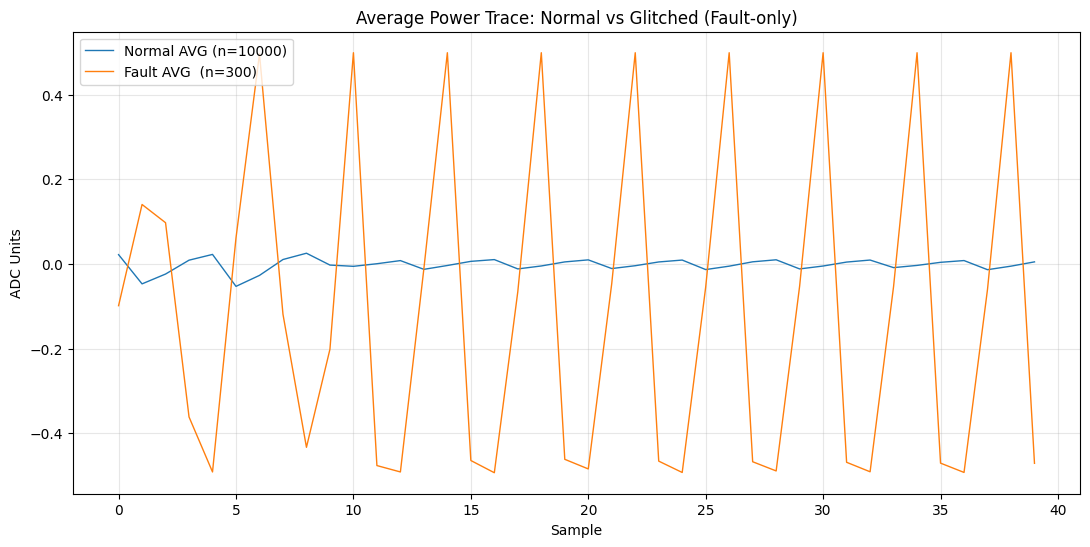

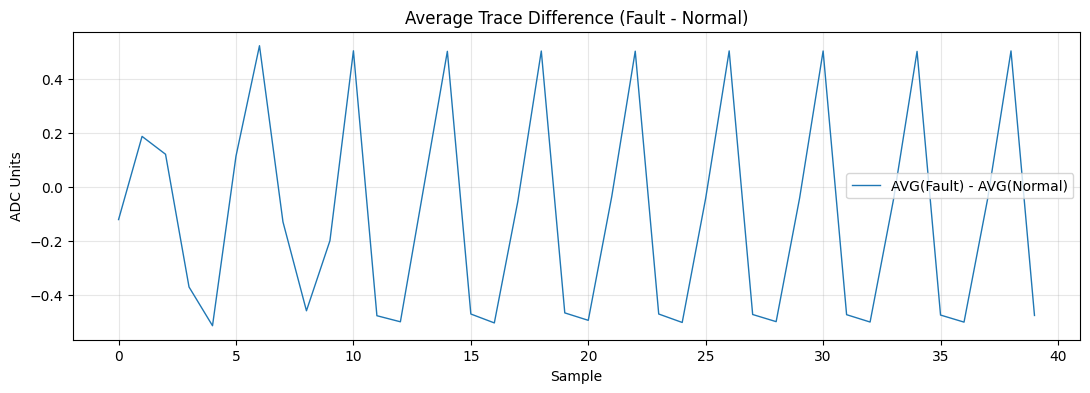

In [16]:
import numpy as np
import matplotlib.pyplot as plt

EXPECTED = bytes(EXPECTED_CIPHERTEXT)

# ---- collect fault-only traces ----
def collect_fault_traces(num_fault_traces=300, max_attempts=5000, verbose_every=200):
    fault_traces = []
    fault_outputs = []
    attempts = 0
    timeouts = 0
    ok_reads = 0
    normals = 0
    faults = 0

    while (len(fault_traces) < num_fault_traces) and (attempts < max_attempts):
        attempts += 1
        scope.arm()
        out, ok = run_aes(target, PLAINTEXT, KEY)

        if scope.capture():
            timeouts += 1
            continue

        if (not ok) or (out is None) or (len(out) != 16):
            continue

        ok_reads += 1

        if out == EXPECTED:
            normals += 1
            continue

        # fault
        faults += 1
        fault_traces.append(np.array(scope.get_last_trace(), dtype=np.float32))
        fault_outputs.append(bytes(out))

        if verbose_every and (attempts % verbose_every == 0):
            print(f"attempts={attempts}  collected_faults={len(fault_traces)}  "
                  f"ok_reads={ok_reads}  normals={normals}  faults={faults}  timeouts={timeouts}")

    print("\n--- Fault trace collection summary ---")
    print(f"attempts={attempts}, collected_fault_traces={len(fault_traces)}")
    print(f"ok_reads={ok_reads}, normals={normals}, faults={faults}, timeouts={timeouts}")
    return fault_traces, fault_outputs

# Choose how many fault traces you want to average (100–1000 is typical)
fault_traces, fault_outputs = collect_fault_traces(num_fault_traces=300, max_attempts=8000)

# ---- compute averages ----
normal_avg = np.mean(np.asarray(normal_traces, dtype=np.float32), axis=0)

fault_avg  = np.mean(np.asarray(fault_traces, dtype=np.float32), axis=0)

# ---- plot average normal vs average fault ----
plt.figure(figsize=(13, 6))
plt.plot(normal_avg, label=f"Normal AVG (n={len(normal_traces)})", linewidth=1)
plt.plot(fault_avg,  label=f"Fault AVG  (n={len(fault_traces)})", linewidth=1)

plt.title("Average Power Trace: Normal vs Glitched (Fault-only)")
plt.xlabel("Sample")
plt.ylabel("ADC Units")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ---- plot difference (fault_avg - normal_avg) ----
plt.figure(figsize=(13, 4))
plt.plot(fault_avg - normal_avg, label="AVG(Fault) - AVG(Normal)", linewidth=1)
plt.title("Average Trace Difference (Fault - Normal)")
plt.xlabel("Sample")
plt.ylabel("ADC Units")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


i=500/10000  collected=500  normals=23  faults=477  timeouts=0  bad_reads=0
i=1000/10000  collected=1000  normals=47  faults=953  timeouts=0  bad_reads=0
i=1500/10000  collected=1500  normals=72  faults=1428  timeouts=0  bad_reads=0
i=2000/10000  collected=2000  normals=102  faults=1898  timeouts=0  bad_reads=0
i=2500/10000  collected=2500  normals=130  faults=2370  timeouts=0  bad_reads=0
i=3000/10000  collected=3000  normals=156  faults=2844  timeouts=0  bad_reads=0
i=3500/10000  collected=3500  normals=172  faults=3328  timeouts=0  bad_reads=0
i=4000/10000  collected=4000  normals=197  faults=3803  timeouts=0  bad_reads=0
i=4500/10000  collected=4500  normals=218  faults=4282  timeouts=0  bad_reads=0
i=5000/10000  collected=5000  normals=253  faults=4747  timeouts=0  bad_reads=0
i=5500/10000  collected=5500  normals=274  faults=5226  timeouts=0  bad_reads=0
i=6000/10000  collected=6000  normals=300  faults=5700  timeouts=0  bad_reads=0
i=6500/10000  collected=6500  normals=323  faul

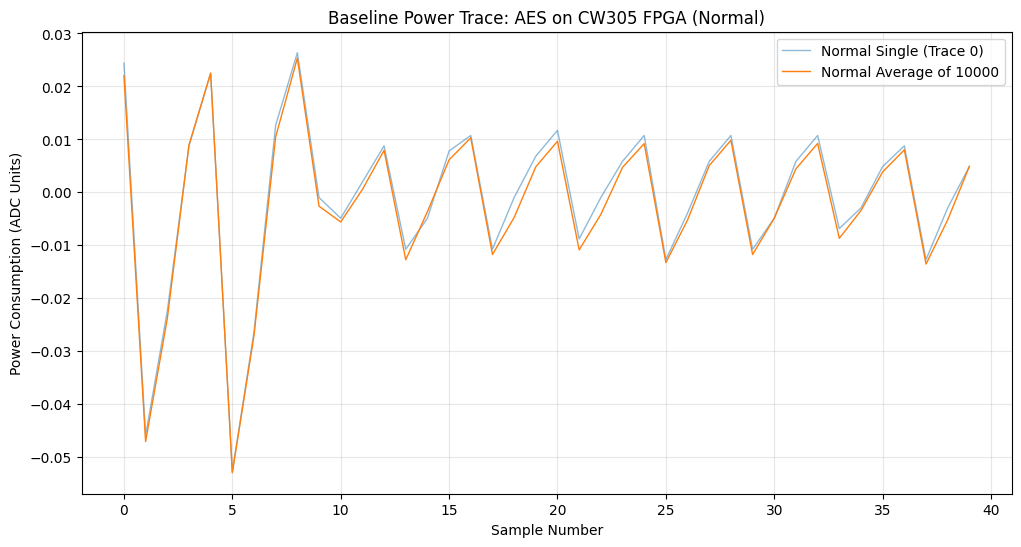

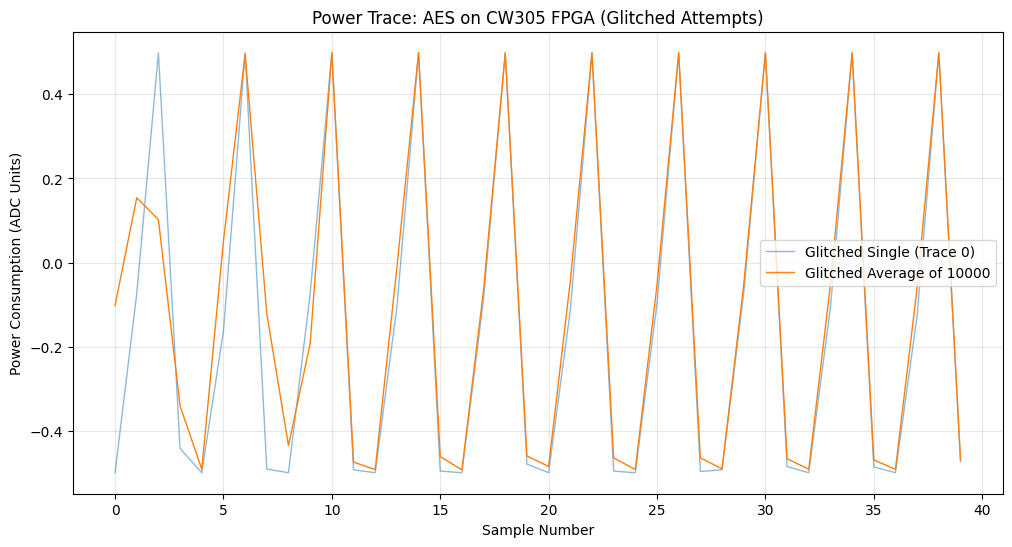

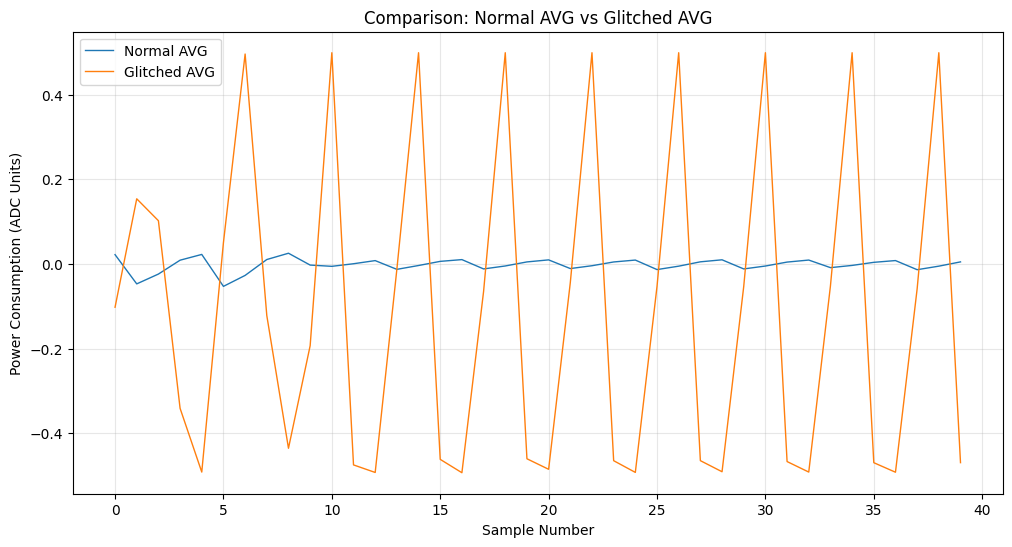

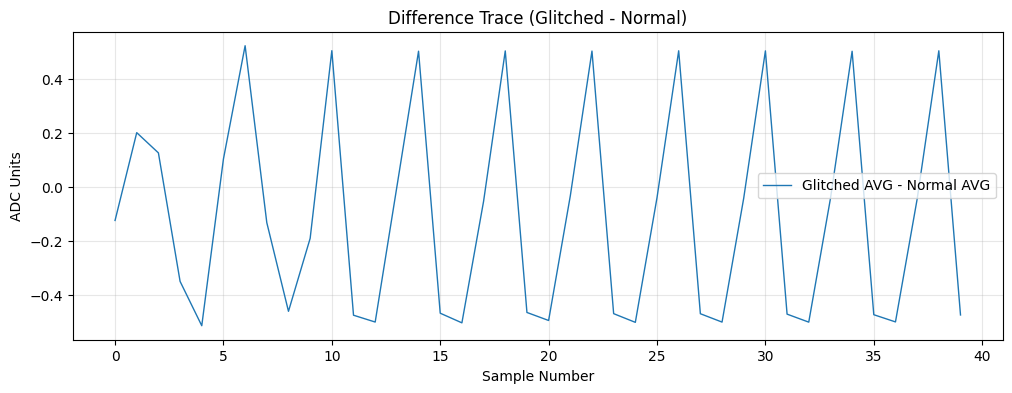

In [17]:
import numpy as np
import matplotlib.pyplot as plt

EXPECTED = bytes(EXPECTED_CIPHERTEXT)

# ---------- 1) Collect 10,000 GLITCHED traces ----------
def collect_glitched_traces(N=10000, verbose_every=500):
    glitched_traces = []
    normals = 0
    faults = 0
    timeouts = 0
    bad_reads = 0

    for i in range(N):
        scope.arm()
        out, ok = run_aes(target, PLAINTEXT, KEY)

        if scope.capture():
            timeouts += 1
            continue

        if (not ok) or (out is None) or (len(out) != 16):
            bad_reads += 1
            continue

        trace = np.array(scope.get_last_trace(), dtype=np.float32)
        glitched_traces.append(trace)

        if bytes(out) == EXPECTED:
            normals += 1
        else:
            faults += 1

        if verbose_every and ((i+1) % verbose_every == 0):
            print(f"i={i+1}/{N}  collected={len(glitched_traces)}  normals={normals}  faults={faults}  timeouts={timeouts}  bad_reads={bad_reads}")

    print("\n--- Glitch collection done ---")
    print(f"Requested={N}, Collected={len(glitched_traces)}")
    print(f"Normals={normals}, Faults={faults}, Timeouts={timeouts}, BadReads={bad_reads}")
    return glitched_traces

# ✅ make sure glitch is ON before calling this:
# scope.io.glitch_lp = True
# scope.io.glitch_hp = False
# scope.glitch.trigger_src = 'ext_single'
# scope.glitch.width = ...
# scope.glitch.offset = ...

glitched_traces = collect_glitched_traces(N=10000, verbose_every=500)

if len(glitched_traces) == 0:
    raise RuntimeError("No glitched traces collected. Check trigger/glitch setup and try again.")

# ---------- 2) Compute averages ----------
normal_avg  = np.mean(np.asarray(normal_traces, dtype=np.float32), axis=0)
glitch_avg  = np.mean(np.asarray(glitched_traces, dtype=np.float32), axis=0)

normal_one  = np.array(normal_traces[0], dtype=np.float32)
glitch_one  = np.array(glitched_traces[0], dtype=np.float32)

# ---------- 3) Plot like your baseline (Normal) ----------
plt.figure(figsize=(12, 6))
plt.plot(normal_one, label="Normal Single (Trace 0)", alpha=0.5, linewidth=1)
plt.plot(normal_avg, label=f"Normal Average of {len(normal_traces)}", linewidth=1)
plt.title("Baseline Power Trace: AES on CW305 FPGA (Normal)")
plt.xlabel("Sample Number")
plt.ylabel("Power Consumption (ADC Units)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ---------- 4) Plot like your baseline (Glitched) ----------
plt.figure(figsize=(12, 6))
plt.plot(glitch_one, label="Glitched Single (Trace 0)", alpha=0.5, linewidth=1)
plt.plot(glitch_avg, label=f"Glitched Average of {len(glitched_traces)}", linewidth=1)
plt.title("Power Trace: AES on CW305 FPGA (Glitched Attempts)")
plt.xlabel("Sample Number")
plt.ylabel("Power Consumption (ADC Units)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ---------- 5) Compare averages on same plot ----------
plt.figure(figsize=(12, 6))
plt.plot(normal_avg, label="Normal AVG", linewidth=1)
plt.plot(glitch_avg, label="Glitched AVG", linewidth=1)
plt.title("Comparison: Normal AVG vs Glitched AVG")
plt.xlabel("Sample Number")
plt.ylabel("Power Consumption (ADC Units)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ---------- 6) Optional difference plot ----------
plt.figure(figsize=(12, 4))
plt.plot(glitch_avg - normal_avg, label="Glitched AVG - Normal AVG", linewidth=1)
plt.title("Difference Trace (Glitched - Normal)")
plt.xlabel("Sample Number")
plt.ylabel("ADC Units")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Collected normals: 132 faults: 2000


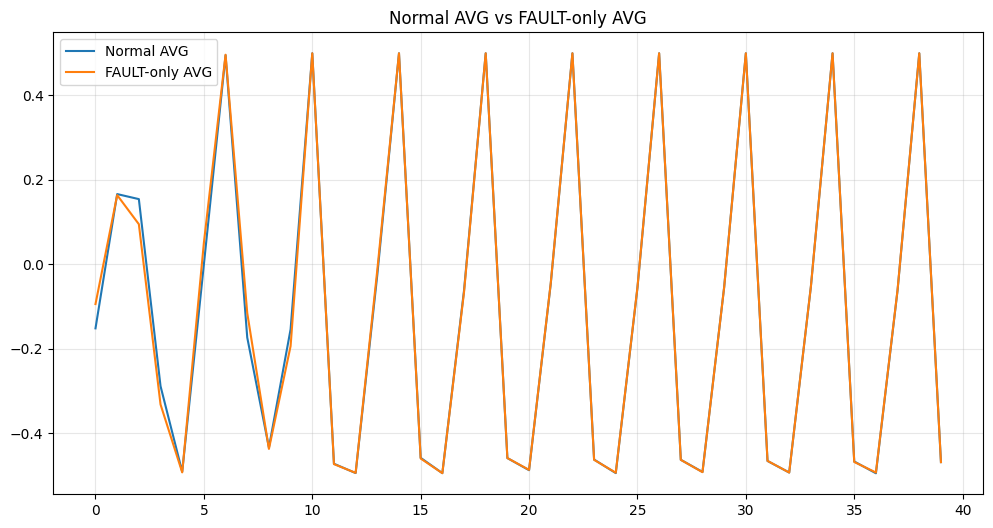

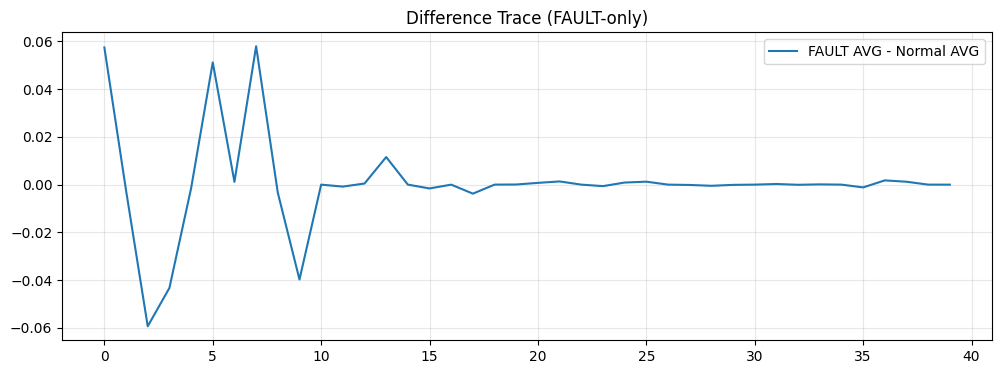

In [18]:
import numpy as np
import matplotlib.pyplot as plt

EXPECTED = bytes(EXPECTED_CIPHERTEXT)

fault_traces = []
normal_traces_2 = []

N_FAULT = 2000  # start smaller, then increase
max_attempts = 50000

attempts = 0
while len(fault_traces) < N_FAULT and attempts < max_attempts:
    attempts += 1
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    if scope.capture() or (not ok) or out is None:
        continue

    tr = np.array(scope.get_last_trace(), dtype=np.float32)

    if bytes(out) == EXPECTED:
        normal_traces_2.append(tr)
    else:
        fault_traces.append(tr)

print("Collected normals:", len(normal_traces_2), "faults:", len(fault_traces))

normal_avg = np.mean(np.asarray(normal_traces_2), axis=0)
fault_avg  = np.mean(np.asarray(fault_traces), axis=0)

plt.figure(figsize=(12,6))
plt.plot(normal_avg, label="Normal AVG")
plt.plot(fault_avg, label="FAULT-only AVG")
plt.title("Normal AVG vs FAULT-only AVG")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

plt.figure(figsize=(12,4))
plt.plot(fault_avg - normal_avg, label="FAULT AVG - Normal AVG")
plt.title("Difference Trace (FAULT-only)")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()


In [15]:
print(scope.clock.adc_src, scope.gain.gain, scope.trigger.triggers, scope.adc.basic_mode, scope.adc.samples)


extclk_x4 25 tio4 falling_edge 400


In [19]:
import numpy as np

print("normal_avg min/max:", float(np.min(normal_avg)), float(np.max(normal_avg)))
print("fault_avg  min/max:", float(np.min(fault_avg)),  float(np.max(fault_avg)))
print("diff       min/max:", float(np.min(fault_avg-normal_avg)), float(np.max(fault_avg-normal_avg)))

corr = np.corrcoef(normal_avg, fault_avg)[0,1]
print("corr(normal_avg, fault_avg) =", float(corr))


normal_avg min/max: -0.49419981241226196 0.4990234375
fault_avg  min/max: -0.49394237995147705 0.4990234375
diff       min/max: -0.05934729427099228 0.05796077102422714
corr(normal_avg, fault_avg) = 0.9985927667856344


In [20]:

SBOX = [
0x63,0x7c,0x77,0x7b,0xf2,0x6b,0x6f,0xc5,0x30,0x01,0x67,0x2b,0xfe,0xd7,0xab,0x76,
0xca,0x82,0xc9,0x7d,0xfa,0x59,0x47,0xf0,0xad,0xd4,0xa2,0xaf,0x9c,0xa4,0x72,0xc0,
0xb7,0xfd,0x93,0x26,0x36,0x3f,0xf7,0xcc,0x34,0xa5,0xe5,0xf1,0x71,0xd8,0x31,0x15,
0x04,0xc7,0x23,0xc3,0x18,0x96,0x05,0x9a,0x07,0x12,0x80,0xe2,0xeb,0x27,0xb2,0x75,
0x09,0x83,0x2c,0x1a,0x1b,0x6e,0x5a,0xa0,0x52,0x3b,0xd6,0xb3,0x29,0xe3,0x2f,0x84,
0x53,0xd1,0x00,0xed,0x20,0xfc,0xb1,0x5b,0x6a,0xcb,0xbe,0x39,0x4a,0x4c,0x58,0xcf,
0xd0,0xef,0xaa,0xfb,0x43,0x4d,0x33,0x85,0x45,0xf9,0x02,0x7f,0x50,0x3c,0x9f,0xa8,
0x51,0xa3,0x40,0x8f,0x92,0x9d,0x38,0xf5,0xbc,0xb6,0xda,0x21,0x10,0xff,0xf3,0xd2,
0xcd,0x0c,0x13,0xec,0x5f,0x97,0x44,0x17,0xc4,0xa7,0x7e,0x3d,0x64,0x5d,0x19,0x73,
0x60,0x81,0x4f,0xdc,0x22,0x2a,0x90,0x88,0x46,0xee,0xb8,0x14,0xde,0x5e,0x0b,0xdb,
0xe0,0x32,0x3a,0x0a,0x49,0x06,0x24,0x5c,0xc2,0xd3,0xac,0x62,0x91,0x95,0xe4,0x79,
0xe7,0xc8,0x37,0x6d,0x8d,0xd5,0x4e,0xa9,0x6c,0x56,0xf4,0xea,0x65,0x7a,0xae,0x08,
0xba,0x78,0x25,0x2e,0x1c,0xa6,0xb4,0xc6,0xe8,0xdd,0x74,0x1f,0x4b,0xbd,0x8b,0x8a,
0x70,0x3e,0xb5,0x66,0x48,0x03,0xf6,0x0e,0x61,0x35,0x57,0xb9,0x86,0xc1,0x1d,0x9e,
0xe1,0xf8,0x98,0x11,0x69,0xd9,0x8e,0x94,0x9b,0x1e,0x87,0xe9,0xce,0x55,0x28,0xdf,
0x8c,0xa1,0x89,0x0d,0xbf,0xe6,0x42,0x68,0x41,0x99,0x2d,0x0f,0xb0,0x54,0xbb,0x16
]

INV_SBOX = [0]*256
for i,v in enumerate(SBOX):
    INV_SBOX[v] = i

RCON = [0x00,0x01,0x02,0x04,0x08,0x10,0x20,0x40,0x80,0x1B,0x36]

def rot_word(w):  # 4 bytes
    return w[1:]+w[:1]

def sub_word(w):
    return [SBOX[b] for b in w]

def xor_bytes(a,b):
    return bytes([x^y for x,y in zip(a,b)])

def bytes_to_state(b16):
    # AES state is 4x4 column-major
    # state[r][c] = b16[r + 4*c]
    s = [[0]*4 for _ in range(4)]
    for c in range(4):
        for r in range(4):
            s[r][c] = b16[r + 4*c]
    return s

def state_to_bytes(s):
    out = bytearray(16)
    for c in range(4):
        for r in range(4):
            out[r + 4*c] = s[r][c]
    return bytes(out)

def shift_rows(s):
    for r in range(1,4):
        s[r] = s[r][r:] + s[r][:r]
    return s

def inv_shift_rows(s):
    for r in range(1,4):
        s[r] = s[r][-r:] + s[r][:-r]
    return s

def sub_bytes(s):
    for r in range(4):
        for c in range(4):
            s[r][c] = SBOX[s[r][c]]
    return s

def inv_sub_bytes(s):
    for r in range(4):
        for c in range(4):
            s[r][c] = INV_SBOX[s[r][c]]
    return s

def add_round_key(s, rk16):
    rk = bytes_to_state(rk16)
    for r in range(4):
        for c in range(4):
            s[r][c] ^= rk[r][c]
    return s

def key_expansion_aes128(key16: bytes):
    assert len(key16)==16
    w = [list(key16[i:i+4]) for i in range(0,16,4)]  # 4 words
    for i in range(4, 44):
        temp = w[i-1].copy()
        if i % 4 == 0:
            temp = sub_word(rot_word(temp))
            temp[0] ^= RCON[i//4]
        w.append([w[i-4][j]^temp[j] for j in range(4)])
    # round keys: 11 * 16 bytes
    round_keys = []
    for r in range(11):
        rk = sum(w[4*r:4*r+4], [])  # flatten 4 words
        round_keys.append(bytes(rk))
    return round_keys

# ---------------- Round mapping helpers ----------------

def pullback_after_final_round(cipher16: bytes, rk10: bytes):
    """
    Compute X10 = InvShiftRows( C ^ rk10 )
    This is the state right before SubBytes in round 10.
    """
    s = bytes_to_state(xor_bytes(cipher16, rk10))
    s = inv_shift_rows(s)
    return state_to_bytes(s)

def hamming_weight_bytes(b):
    return sum(bin(x).count("1") for x in b)

def nonzero_positions(b):
    return [i for i,x in enumerate(b) if x!=0]

def analyze_faults_round9_vs_round10(expected_ct, fault_ct_list, key16):
    rks = key_expansion_aes128(key16)
    rk10 = rks[10]

    # Pull back expected once
    x10_exp = pullback_after_final_round(expected_ct, rk10)

    results = []
    for fc in fault_ct_list:
        x10_f = pullback_after_final_round(fc, rk10)
        delta_x10 = xor_bytes(x10_exp, x10_f)

        # Heuristics:
        # Round-10-late faults tend to look "sparser" after pullback (few bytes differ)
        # Round-9-late faults (before final round) usually diffuse more after SubBytes+ShiftRows+ARK,
        # so after pullback they may still show multiple disturbed bytes/structure, not just single-bit.
        nz = len(nonzero_positions(delta_x10))
        hw = hamming_weight_bytes(delta_x10)

        results.append({
            "fault_ct": fc.hex(),
            "delta_ct_hw": hamming_weight_bytes(xor_bytes(expected_ct, fc)),
            "delta_x10_nz_bytes": nz,
            "delta_x10_hw": hw,
            "delta_x10_hex": delta_x10.hex()
        })

    # Simple decision rule you can refine:
    # - If delta_x10 has very few nonzero bytes (1-2) repeatedly => likely round 10 late
    # - If delta_x10 has broader nonzero bytes (>=4) regularly => likely round 9 late (or earlier)
    return results


In [21]:
# Example: collect 500 faulted ciphertexts (only those != expected)
fault_cts = []

N = 2000
for _ in range(N):
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    if scope.capture() or (not ok) or out is None:
        continue
    if out != bytes(EXPECTED_CIPHERTEXT):
        fault_cts.append(bytes(out))
    if len(fault_cts) >= 500:
        break

print("Collected faults:", len(fault_cts))


Collected faults: 500


In [22]:
expected = bytes(EXPECTED_CIPHERTEXT)
key = bytes(KEY)

res = analyze_faults_round9_vs_round10(expected, fault_cts, key)

# quick summary stats
nz_list = [r["delta_x10_nz_bytes"] for r in res]
print("delta_x10_nz_bytes min/avg/max:", min(nz_list), sum(nz_list)/len(nz_list), max(nz_list))

# show most common delta_x10 patterns
from collections import Counter
ctr = Counter([r["delta_x10_hex"] for r in res])
print("Top 10 delta_x10 patterns:")
for pat,c in ctr.most_common(10):
    print(c, pat)


delta_x10_nz_bytes min/avg/max: 1 1.954 4
Top 10 delta_x10 patterns:
65 00000020000000000000000000000000
43 00000000000000000000000000000300
32 00010000200000000000000200000000
30 00000000000000020000220000000000
26 00002200002300000000000000000000
23 02000000000000000000000000230000
21 02000000000000000000000000000000
17 00000000000000000000000001000021
13 00000000000000020000000000000020
13 00000000000023000020000000000000


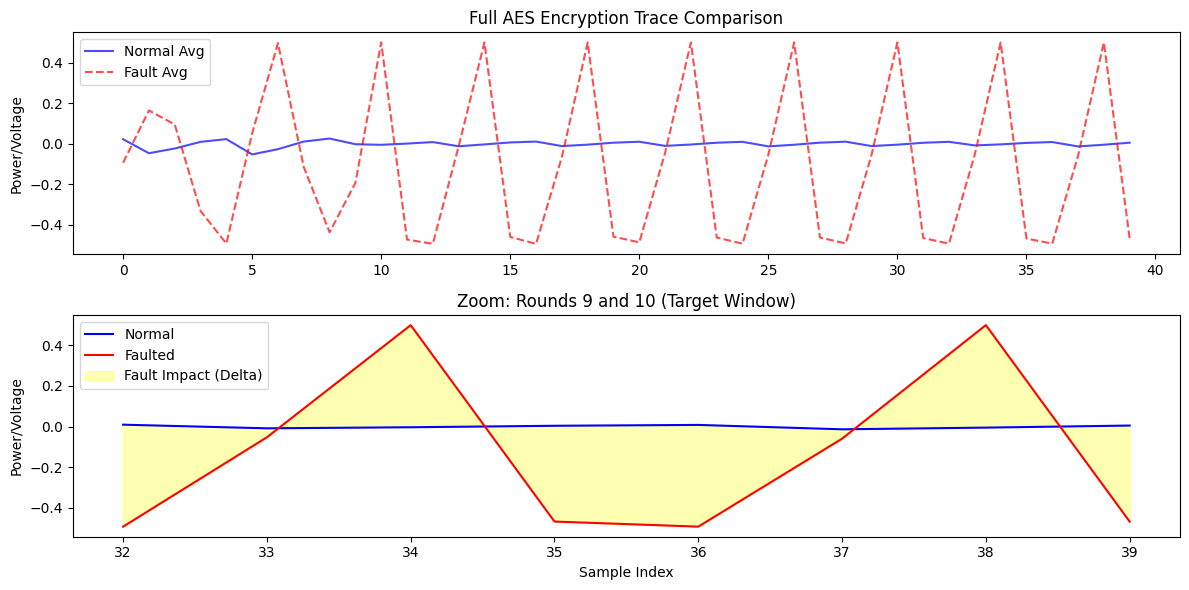

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming you have your trace arrays from your experiment:
# normal_traces (the golden traces)
# fault_traces (the glitched traces)

# 1. Calculate the averages to reduce noise
normal_avg = np.average(normal_traces, axis=0)
fault_avg = np.average(fault_traces, axis=0)

# 2. Determine the "Zoom" window
# AES-128 traces usually have the most interesting part at the very end.
# We will look at the last 20% of the trace.
total_samples = len(normal_avg)
start_zoom = int(total_samples * 0.8) 
end_zoom = total_samples

# 3. Create the Visualization
plt.figure(figsize=(12, 6))

# Subplot 1: The Full Trace
plt.subplot(2, 1, 1)
plt.plot(normal_avg, label='Normal Avg', alpha=0.7, color='blue')
plt.plot(fault_avg, label='Fault Avg', alpha=0.7, color='red', linestyle='--')
plt.title("Full AES Encryption Trace Comparison")
plt.ylabel("Power/Voltage")
plt.legend()

# Subplot 2: Zoomed into Round 9 & 10
plt.subplot(2, 1, 2)
plt.plot(range(start_zoom, end_zoom), normal_avg[start_zoom:end_zoom], label='Normal', color='blue')
plt.plot(range(start_zoom, end_zoom), fault_avg[start_zoom:end_zoom], label='Faulted', color='red')

# Highlight the delta (the difference)
diff = np.abs(normal_avg - fault_avg)
plt.fill_between(range(start_zoom, end_zoom), 
                 normal_avg[start_zoom:end_zoom], 
                 fault_avg[start_zoom:end_zoom], 
                 color='yellow', alpha=0.3, label='Fault Impact (Delta)')

plt.title("Zoom: Rounds 9 and 10 (Target Window)")
plt.xlabel("Sample Index")
plt.ylabel("Power/Voltage")
plt.legend()

plt.tight_layout()
plt.savefig("fault_analysis_zoom.png")

C:\Users\sbista\ChipWhisperer\cwenv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:618: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)


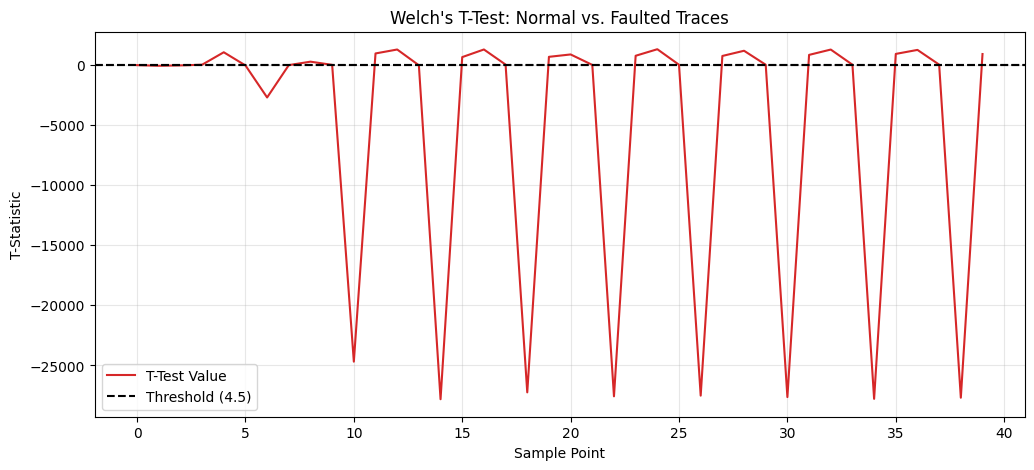

In [24]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

def perform_t_test(normal_traces, fault_traces):
    # Convert to numpy arrays if they aren't already
    group_a = np.array(normal_traces)
    group_b = np.array(fault_traces)

    # Perform Welch's T-test (equal_var=False) for each sample point
    t_map, _ = stats.ttest_ind(group_a, group_b, axis=0, equal_var=False)
    
    return t_map

# Run the test
t_values = perform_t_test(normal_traces, fault_traces)

# Plotting the results
plt.figure(figsize=(12, 5))
plt.plot(t_values, color='tab:red', label='T-Test Value')
plt.axhline(y=4.5, color='black', linestyle='--', label='Threshold (4.5)')
plt.axhline(y=-4.5, color='black', linestyle='--')

plt.title("Welch's T-Test: Normal vs. Faulted Traces")
plt.xlabel("Sample Point")
plt.ylabel("T-Statistic")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [25]:
def verify_diffusion_columns(res_list):
    columns = {
        "Col 0": {0, 5, 10, 15},
        "Col 1": {4, 9, 14, 3},
        "Col 2": {8, 13, 2, 7},
        "Col 3": {12, 1, 6, 11}
    }
    
    for r in res_list:
        if r["delta_x10_nz_bytes"] == 4:
            # Get the indices of the non-zero bytes
            diff_bytes = bytes.fromhex(r["delta_x10_hex"])
            nz_indices = set(i for i, b in enumerate(diff_bytes) if b != 0)
            
            # Check which column it matches
            matched = False
            for col_name, col_indices in columns.items():
                if nz_indices == col_indices:
                    print(f"Verified: Fault at {r['delta_x10_hex'][:8]}... matches {col_name}")
                    matched = True
                    break
            if not matched:
                print(f"Warning: Fault indices {nz_indices} do not match standard AES columns.")

# Run the analysis on your 'res' variable from your image
verify_diffusion_columns(res)

Data shapes: Normal=(10000, 40), Fault=(2000, 40)

--- DIFFUSION ANALYSIS RESULTS ---
Col 0: 0 occurrences
Col 1: 0 occurrences
Col 2: 0 occurrences
Col 3: 0 occurrences
Single-Byte: 71 occurrences
Unknown: 3 occurrences


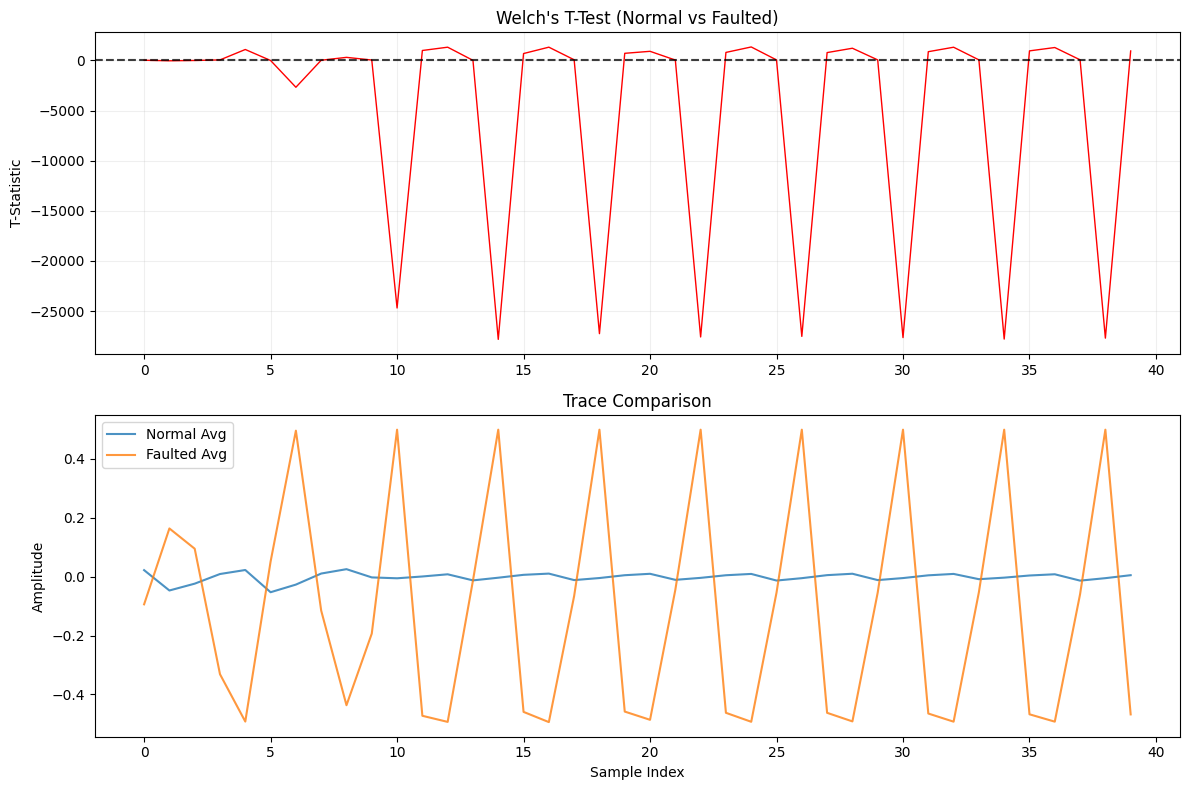

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --- 1. DATA PREPARATION ---
# Convert lists to NumPy arrays for faster math
# We use float32 to save memory while maintaining precision
np_normal = np.array(normal_traces, dtype=np.float32)
np_fault = np.array(fault_traces, dtype=np.float32)

print(f"Data shapes: Normal={np_normal.shape}, Fault={np_fault.shape}")

# --- 2. WELCH'S T-TEST (The Hardware Proof) ---
# We calculate the T-statistic for every single sample point
t_stat, p_val = stats.ttest_ind(np_normal, np_fault, axis=0, equal_var=False)

# --- 3. MULTI-BYTE DIFFUSION (The Mathematical Proof) ---
# AES Column Indices
columns = {
    "Column 0": {0, 5, 10, 15},
    "Column 1": {4, 9, 14, 3},
    "Column 2": {8, 13, 2, 7},
    "Column 3": {12, 1, 6, 11}
}

# Run the pullback analysis on our collected fault outputs
res_analysis = analyze_faults_round9_vs_round10(EXPECTED_CIPHERTEXT, fault_outputs, KEY)

diff_counts = {"Col 0": 0, "Col 1": 0, "Col 2": 0, "Col 3": 0, "Single-Byte": 0, "Unknown": 0}

for r in res_analysis:
    if r["delta_x10_nz_bytes"] == 1:
        diff_counts["Single-Byte"] += 1
    elif r["delta_x10_nz_bytes"] == 4:
        diff_bytes = bytes.fromhex(r["delta_x10_hex"])
        nz_indices = set(i for i, b in enumerate(diff_bytes) if b != 0)
        
        matched = False
        for col_name, col_indices in columns.items():
            if nz_indices == col_indices:
                diff_counts[col_name.replace("umn", "")] += 1
                matched = True
        if not matched: diff_counts["Unknown"] += 1

# --- 4. OUTPUT RESULTS ---
print("\n--- DIFFUSION ANALYSIS RESULTS ---")
for key, val in diff_counts.items():
    print(f"{key}: {val} occurrences")

# --- 5. VISUALIZATION ---
plt.figure(figsize=(12, 8))

# Subplot 1: T-Test
plt.subplot(2, 1, 1)
plt.plot(t_stat, color='red', linewidth=1)
plt.axhline(y=4.5, color='black', linestyle='--', alpha=0.5)
plt.axhline(y=-4.5, color='black', linestyle='--', alpha=0.5)
plt.title("Welch's T-Test (Normal vs Faulted)")
plt.ylabel("T-Statistic")
plt.grid(True, alpha=0.2)

# Subplot 2: Average Traces (for visual alignment)
plt.subplot(2, 1, 2)
plt.plot(np.mean(np_normal, axis=0), label="Normal Avg", alpha=0.8)
plt.plot(np.mean(np_fault, axis=0), label="Faulted Avg", alpha=0.8)
plt.title("Trace Comparison")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()

plt.tight_layout()
plt.show() # This ensures the plot actually pops up

In [28]:
# Check if your 4-byte faults all belong to the same 'Column'
# If they do, your 8 spikes are physically hitting that specific Column's logic.
for r in res:
    if r["delta_x10_nz_bytes"] == 4:
        diff_bytes = bytes.fromhex(r["delta_x10_hex"])
        # AES Column 0 is indices 0, 5, 10, 15
        if all(diff_bytes[i] != 0 for i in [0, 5, 10, 15]):
            print(f"CONFIRMED: Spike hit Round 9, Column 0. Mask: {r['delta_x10_hex']}")

In [29]:
# 1. Center the data by subtracting the mean
normal_centered = np_normal - np.mean(np_normal, axis=0)
fault_centered = np_fault - np.mean(np_fault, axis=0)

# 2. Square the results to look at variance/power
normal_squared = normal_centered**2
fault_squared = fault_centered**2

# 3. Perform T-test on the squared data
t_stat_2nd, _ = stats.ttest_ind(normal_squared, fault_squared, axis=0, equal_var=False)
